In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math
import glob

# Helper Functions

In [2]:
# ========================================
# Helper function to plot the coordinates
# ========================================

def plot_coords(x_coord, y_coord, coords_type):

    plt.figure(figsize=(5, 5))
    plt.scatter(x_coord, y_coord, color='blue', s=0)
    # Instead of using points to represent cities I put the city index in place of the marker
    for i in range(len(x_coord)):
        plt.text(x_coord[i], y_coord[i], str(i+1), fontsize=10, ha='center', va='center', c="b")
    plt.title('City Coordinates on a ' + coords_type)
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')

    if (coords_type == "Square"):
            plt.plot([0, 1, 1, 0, 0], [0, 0, 1, 1, 0], color='red', linestyle='--', linewidth=1)

    plt.grid()
    plt.show()

In [24]:
# ========================================
# Helper function to plot fitness
# ========================================

def plot_fitness(filename):
    generations = []
    fitnesses = []
    
    with open('outputs/' + filename, 'r') as f:
        for line in f:
            # Delete the text strings from the line
            clean_line = line.replace("Generation", "").replace("| Best Fitness:", "")
            parts = clean_line.split()
            
            # If we are left with exactly two numbers, save them
            if len(parts) == 2:
                generations.append(int(parts[0]))
                fitnesses.append(float(parts[1]))

    # Plotting
    plt.figure(figsize=(10, 6))
    plt.plot(generations, fitnesses, color='purple', linewidth=2.5, label='Global Best Fitness')
    
    plt.title('Island Model: Global Best Fitness vs Generation', fontsize=14)
    plt.xlabel('Generation', fontsize=12)
    plt.ylabel('$L^{(1)}$ Tour Length', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

In [35]:
# ========================================
# Helper function to plot best tour
# ========================================

def plot_tour(filename_tour, filename_coordinates):

    # np.loadtxt automatically ignores the header starting with '#'
    data = np.loadtxt('outputs/' + filename_tour)

    # Extract the fitness (the first number)
    final_fitness = data[0]

    # Extract the sequence of cities (convert to 0 base indexes)
    tour_sequence = data[1:].astype(int) - 1

    # Load spatial coordinates
    coords = np.loadtxt('input/' + filename_coordinates)

    # Map the coordinates to the tour sequence
    x_route = coords[tour_sequence, 0]
    y_route = coords[tour_sequence, 1]

    plt.figure(figsize=(7, 7))
    plt.plot(x_route, y_route, marker='o', linestyle='-', color='dodgerblue', markersize=5, linewidth=1.5, alpha=0.8)
    # Plot the final map
    # Highlight the starting city with a red star
    plt.plot(x_route[0], y_route[0], marker='*', color='red', markersize=15, label='Start/End City')


    plt.title(f"Parallel GA Optimal Tour \n Final Fitness: {final_fitness:.2f}", fontsize=14)
    plt.xlabel("X Coordinate")
    plt.ylabel("Y Coordinate")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.axis('equal') 
    plt.show()


# Exercise 10: Travelling Salesman Problem and Genetic Algorithm - Parallelization

The aim of this exercise is the parallelization of the Genetic Algorithm in `Lab09` and the efficient application to the real-world problem of the tour of the Italian Provinces.

For the core algorithm implementation refer to the notebook `analysis9.ipynb` in `Lab09`.

## The Island Model and Migration

While parallelizing the algorithm allows us to explore multiple evolutionary paths simultaneously, the true power of this distributed approach is unlocked through **Migration**. We treat each MPI node as an isolated "Continent" running an independent Genetic Search. However, to prevent populations from stagnating in local minima, we periodically allow them to share their genetic breakthroughs.

Every $N_{migr}$ generations, two randomly selected Continents exchange their absolute best individuals (their "Champions"). 

### Implementation Details

The migration mechanics are split between the `Population` class and the MPI communication protocol in `exercise10.cpp.cpp`:

**1. The `ExchangeBest` Method (`Population` class):**
When a Continent receives a foreign tour array, this method constructs a new `Individual` from that genetic sequence and uses it to overwrite its own current best individual. The population is then immediately re-sorted to ensure the new immigrant is placed in its correct rank based on its fitness.

**2. The MPI Communication Protocol (`exercise10.cpp`):**
To coordinate the exchange without causing communication deadlocks across the cluster, I employed a synchronized protocol managed by Rank 0:
* **Selection:** Rank 0 acts as the coordinator, randomly drawing the IDs (ranks) of two distinct nodes to participate in the exchange.
* **Broadcasting:** Rank 0 broadcasts this pair to all other Continents using `MPI_Bcast` so the entire cluster is aware of who is communicating.
* **Partner Identification:** Each node checks the broadcasted pair. If a node finds its own rank in the pair, it assigns the *other* rank to a `partner` variable. For all unselected nodes, this variable remains `-1`.
* **The Exchange:** The two partnered nodes use the `MPI_Sendrecv` function to securely swap their raw genetic arrays (`vector<int>`). Using `MPI_Sendrecv` instead of separate send and receive commands is crucial here, as it automatically schedules the two-way communication and cleanly prevents classic MPI deadlock scenarios.

## MPI Parallelization and Architecture

To transition from a sequential Genetic Search to a parallel Island Model, the code utilizes the Message Passing Interface (MPI) library. The workload is divided among multiple "Continents" (MPI nodes), each running an independent genetic search with its own isolated population.

To ensure that the continents do not perform identical searches, the Random Number Generator is initialized differently for each node. The program reads the Primes file and skips a number of lines equal to the node's rank, guaranteeing unique evolutionary starting points and distinct mutations across the cluster.

**Communication and Logging Roles**
In a distributed memory environment, it is crucial to manage which node handles the input/output operations to prevent file corruption and network bottlenecks. To maximize cluster performance, the algorithm is designed so that only one node interacts with the disk. The responsibilities are divided as follows:

- **All Continents (Ranks 0 to N-1):** 
    - Execute the standard evolutionary loop (`EvolveOneGeneration()`) entirely in local memory.
    - Participate in the Migration Protocol when selected, swapping individuals via `MPI_Sendrecv`.
    - Send their local best fitness to the coordinator at every generation via `MPI_Reduce`.
    - At the end of the simulation, compare results via `MPI_Allreduce` to identify the global champion. The winning node then transmits the final optimal tour sequence to the coordinator.
- **The Coordinator (Rank 0):**
    - Generates the initial city coordinates (if requested) and writes them to a file to ensure all continents solve the exact same spatial problem.
    - Manages the Migration Protocol. Every $N_{migr}$ generations, Rank 0 randomly selects two continents, ensures they are distinct, and broadcasts their identities to the cluster so they can exchange their best individuals via `MPI_Sendrecv`.
    - Handles all disk I/O: Rank 0 is the sole node that writes to the disk. It records the absolute lowest fitness among all continents to the master `output.dat` file every generation, and saves the final optimal sequence of cities to `best_tour.dat` when the evolution is complete.

## Input Configuration Updates

To support the parallel migration features and the specific map of the Italian provinces, several new parameters have been introduced to the input/input.dat configuration file:

```text
N_CITIES            34
POP_SIZE            100
N_GENERATIONS       2000
GENERATE_COORDS     False
COORDS_TYPE         Italy
N_MIGR              10
USE_SYNTHETIC_LOG   1

ENDINPUT
```

The newly introduced parameter `N_MIGR` controls the migration frequency. Every specified number of generations (e.g., 10), two random continents will exchange their absolute best individuals to share genetic breakthroughs and prevent stagnation in local minima.

## Results

### Coordinates plotting

As I did in exercise 09 I plot here a small map of the points that are going to be used in the problem.

In [36]:
latitude, longitude = np.loadtxt("input/cap_prov_ita.dat", unpack=True)
city_names = np.loadtxt("input/prov_ita.txt", dtype=str, usecols=0)

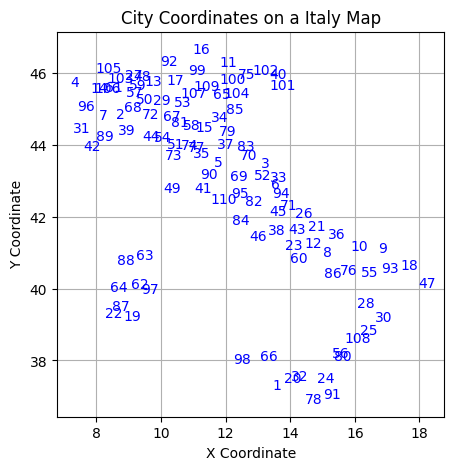

In [37]:
plot_coords(latitude, longitude, "Italy Map")

## Suboptimal results to confront with exercise 9

For the first parallel execution, the algorithm was configured to run on 7 independent continents, each with a population of 100 individuals, for 2000 generations. This setup yields a total equivalent population of 700 individuals across the cluster. This configuration matches the computational budget utilized in the standalone sequential run in Exercise 9, providing a direct baseline to evaluate the performance of the parallel migration mechanism under identical constraints.

### Observations on Parallel Evolution
The plot displays the evolution of the absolute best fitness found across the entire MPI cluster over 2000 generations. Key observations include:
- **Rapid Global Convergence:** The $L^{(1)}$ tour length exhibits a steep initial descent within the first 250 generations. By distributing the computational workload, the algorithm rapidly explores the geometric phase space and quickly identifies highly optimized regions.
- **Stable Plateau:** Following the initial drop, the curve flattens into a stable minimum. Because the migration protocol (`MPI_Sendrecv`) strictly preserves and shares the absolute best individual across the network, the global minimum is protected and incrementally improved without any risk of regression.
- **Algorithmic Efficiency:** The strictly decreasing nature of the curve confirms the effectiveness of the Island Model. Once a superior minimum is discovered by any single node, it propagates through the cluster, ensuring the global search continuously drives the tour length downward to a highly competitive final result.

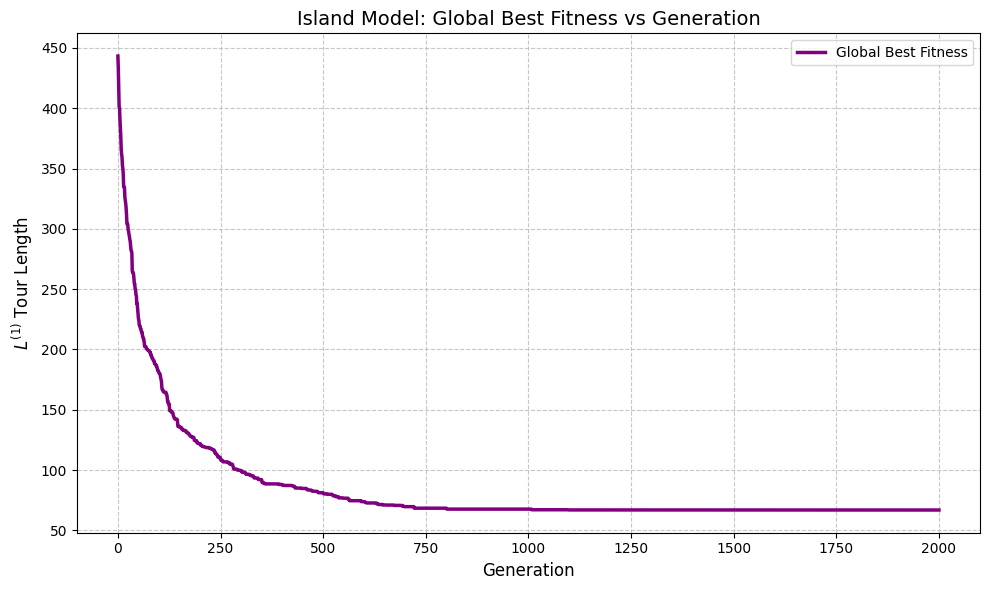

In [45]:
plot_fitness('compare_with9/output.dat')

The best tour obtained after 2000 generations shows significantly better convergence compared to the sequential algorithm running with the same local population size. This improvement occurs because the parallel architecture effectively explores the solution space with a total global population scaled by the number of continents. Consequently, the final result is competitive with the optimal path generated by the sequential algorithm utilizing a single population of 700 individuals.

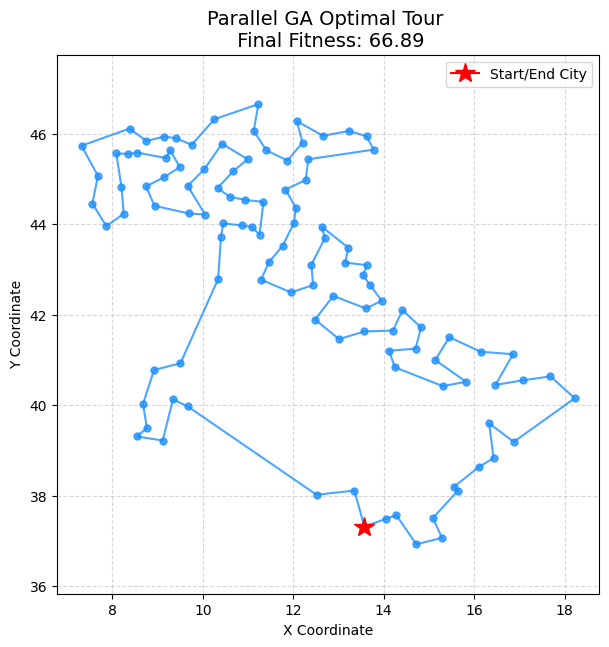

In [46]:
plot_tour('compare_with9/best_tour.dat', 'cap_prov_ita.dat')

## Extended Simulation Run

To further improve the optimization, a final run was executed by increasing the local population size to 700 and extending the limit to 3000 generations. 

* **Larger Population (700):** Sustains genetic diversity for a longer period, allowing the algorithm to broadly explore the geometric phase space and avoid premature trapping in local minima.
* **Extended Generations (3000):** Provides the necessary computational depth for the larger populations to fully converge after exchanging traits via the migration mechanism.

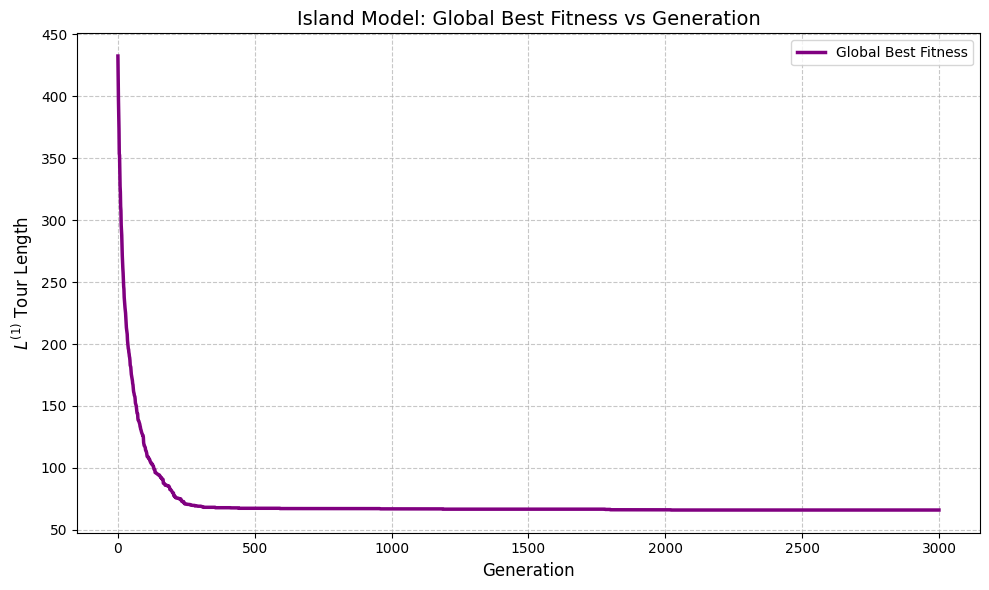

In [47]:
plot_fitness('long_run/output.dat')

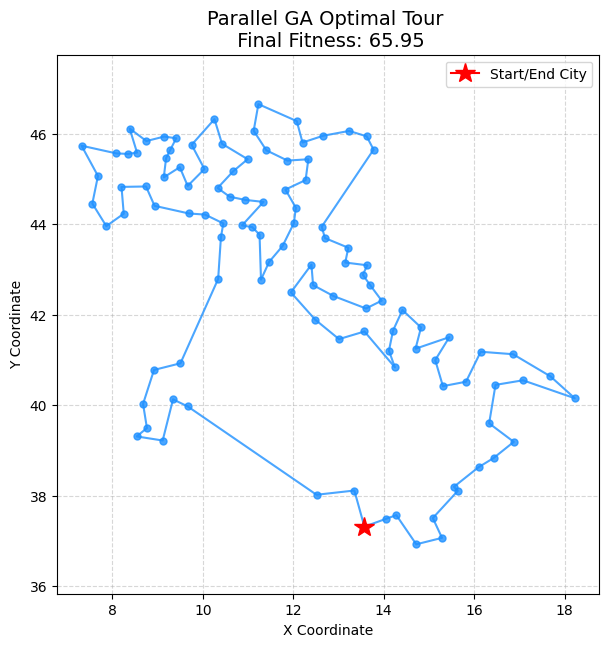

In [48]:
plot_tour('long_run/best_tour.dat', 'cap_prov_ita.dat')